# OrganAMNIST Classification with U-Net ResNet-18 and CFP

This notebook adapts the ICPR U-Net experiments to OrganAMNIST. It compares a U-Net classifier with a ResNet-18 encoder against the same backbone preceded by Connected Filter Preprocessing (CFP). Images are loaded from MedMNIST+ at the native resolution and resized only by `RESIZE_FACTOR`.

In [1]:
# Parameters
RUN_ID = 0
SEED = 42
OUT_DIR = "out_organamnist_unet_resnet18/runs"

DATASET_FLAG = "organamnist"
RESIZE_FACTOR = 1.0
DOWNLOAD_MEDMNIST = True
MEDMNIST_ROOT = None
SMOKE_LIMIT = None

ENCODER_NAME = "resnet18"
ENCODER_WEIGHTS = None
ENCODER_DEPTH = 3
DECODER_CHANNELS = (64, 32, 16)

BATCH_SIZE = 64
NUM_WORKERS = 0
NUM_EPOCHS_BASE = 30
NUM_EPOCHS_CFP = 30
LR = 1e-3
LR_CFP = 5e-2
WEIGHT_DECAY = 1e-7
CFP_SCALE_MODE = "hybrid"
CACHE_EVAL_CFP = True
VAL_CACHE_INDEX_OFFSET = 1_000_000_000
TEST_CACHE_INDEX_OFFSET = 2_000_000_000
DEVICE = "auto"
INSTALL_MISSING = True

In [2]:
# Parameters
RUN_ID = 0
SEED = 2684470948
OUT_DIR = "/Users/wonderalexandre/GitHub/mtlearn/notebooks/ICPR2026_run/out_organamnist_unet_resnet18_smoke/runs"
NUM_EPOCHS_BASE = 1
NUM_EPOCHS_CFP = 1
BATCH_SIZE = 32
SMOKE_LIMIT = 128


## Environment

In [3]:
import importlib
import os
import random
import subprocess
import sys
import time
from pathlib import Path


def ensure_package(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ModuleNotFoundError:
        if not INSTALL_MISSING:
            raise
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or import_name])
        return importlib.import_module(import_name)

ensure_package("medmnist")
ensure_package("segmentation_models_pytorch", "segmentation-models-pytorch")

<module 'segmentation_models_pytorch' from '/opt/anaconda3/lib/python3.12/site-packages/segmentation_models_pytorch/__init__.py'>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from medmnist import INFO
import medmnist
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader, Dataset, Subset
import segmentation_models_pytorch as smp

from mtlearn import morphology
import mtlearn

np.set_printoptions(precision=3, suppress=True)


def fix_randomness(seed: int = 42, deterministic: bool = True):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True, warn_only=True)


def resolve_device(requested="auto"):
    requested = "auto" if requested is None else str(requested).lower()
    if requested == "auto":
        if torch.cuda.is_available():
            return "cuda"
        if torch.backends.mps.is_available():
            return "mps"
        return "cpu"
    if requested == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("DEVICE='cuda' was requested, but CUDA is not available.")
        return "cuda"
    if requested == "mps":
        if not torch.backends.mps.is_available():
            raise RuntimeError("DEVICE='mps' was requested, but MPS is not available.")
        return "mps"
    if requested == "cpu":
        return "cpu"
    raise ValueError("DEVICE must be one of: 'auto', 'cuda', 'mps', or 'cpu'.")

fix_randomness(SEED)
generator = torch.Generator(device="cpu")
generator.manual_seed(SEED)

device = resolve_device(DEVICE)
print("Device:", device)

Device: mps


## Dataset

In [5]:
def validate_factor(name, value):
    value = float(value)
    if not (0.0 < value <= 1.0):
        raise ValueError(f"{name} must satisfy 0 < {name} <= 1. Got {value}.")
    return value


def resolve_medmnist_root(root):
    root = os.environ.get("MEDMNIST_ROOT", root)
    path = Path("downloads/medmnist") if root is None else Path(root).expanduser()
    path.mkdir(parents=True, exist_ok=True)
    return str(path)


class OrganAMNISTDataset(Dataset):
    def __init__(
        self,
        split,
        *,
        resize_factor=1.0,
        root=None,
        download=True,
    ):
        info = INFO[DATASET_FLAG]
        dataset_cls = getattr(medmnist, info["python_class"])
        self.root = resolve_medmnist_root(root)
        self.base = dataset_cls(split=split, root=self.root, download=download)
        self.split = split
        self.info = info
        self.resize_factor = validate_factor("RESIZE_FACTOR", resize_factor)
        self.original_rows, self.original_cols = self._image_hw(self.base[0][0])
        self.target_size = (
            max(1, int(round(self.original_rows * self.resize_factor))),
            max(1, int(round(self.original_cols * self.resize_factor))),
        )

    @staticmethod
    def _image_hw(image):
        arr = np.asarray(image)
        if arr.ndim == 2:
            return arr.shape
        if arr.ndim == 3:
            return arr.shape[:2]
        raise ValueError(f"Unexpected image shape: {arr.shape}")

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        arr = np.asarray(img)
        if arr.ndim == 2:
            arr = arr[None, :, :]
        elif arr.ndim == 3:
            arr = np.moveaxis(arr, -1, 0)
        else:
            raise ValueError(f"Unexpected image shape: {arr.shape}")

        x = torch.from_numpy(np.array(arr, copy=True)).float().div(255.0)
        if x.shape[-2:] != self.target_size:
            x = F.interpolate(
                x.unsqueeze(0),
                size=self.target_size,
                mode="bilinear",
                align_corners=False,
            ).squeeze(0)

        y = int(np.asarray(label).reshape(-1)[0])
        return x, torch.tensor(y, dtype=torch.long), f"{self.split}_{idx:06d}"


def show_samples(dataset, n=8):
    n = min(n, len(dataset))
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.atleast_1d(axes).ravel()
    source_dataset = dataset.dataset if isinstance(dataset, Subset) else dataset
    labels = source_dataset.info["label"]
    for ax, i in zip(axes, range(n)):
        x, y, _ = dataset[i]
        ax.imshow(x[0].numpy(), cmap="gray")
        ax.set_title(f"{int(y)}: {labels[str(int(y))]}")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

SMOKE_LIMIT active: at most 128 samples per split
Dataset: organamnist
Input channels: 1
Classes: 11
Original loaded resolution: 28x28
Resize factor: 1.0
Model resolution: 28x28
Train set: 128
Val set: 128
Test set: 128


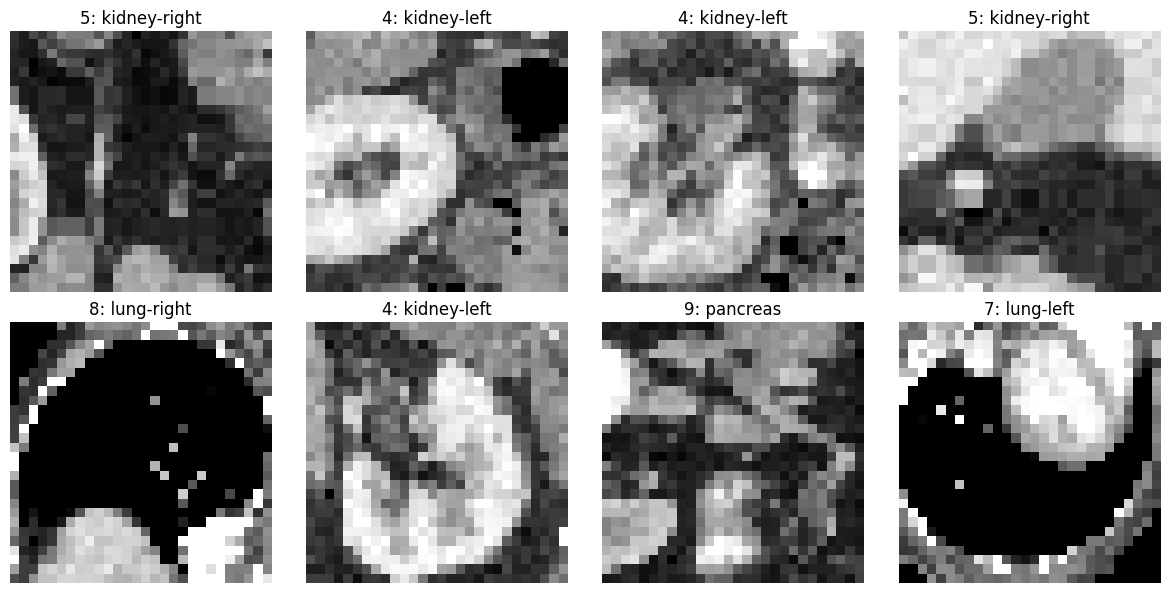

In [6]:
info = INFO[DATASET_FLAG]
n_channels = int(info["n_channels"])
n_classes = len(info["label"])
resize_factor = validate_factor("RESIZE_FACTOR", RESIZE_FACTOR)

def maybe_subset(dataset, limit, seed):
    if limit is None:
        return dataset
    limit = int(limit)
    if limit <= 0 or limit >= len(dataset):
        return dataset
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:limit].tolist()
    return Subset(dataset, indices)

trainset = OrganAMNISTDataset(
    "train",
    resize_factor=RESIZE_FACTOR,
    root=MEDMNIST_ROOT,
    download=DOWNLOAD_MEDMNIST,
)
valset = OrganAMNISTDataset(
    "val",
    resize_factor=RESIZE_FACTOR,
    root=MEDMNIST_ROOT,
    download=DOWNLOAD_MEDMNIST,
)
testset = OrganAMNISTDataset(
    "test",
    resize_factor=RESIZE_FACTOR,
    root=MEDMNIST_ROOT,
    download=DOWNLOAD_MEDMNIST,
)

if SMOKE_LIMIT is not None:
    trainset = maybe_subset(trainset, SMOKE_LIMIT, SEED)
    valset = maybe_subset(valset, SMOKE_LIMIT, SEED + 1)
    testset = maybe_subset(testset, SMOKE_LIMIT, SEED + 2)
    print(f"SMOKE_LIMIT active: at most {SMOKE_LIMIT} samples per split")

trainset_source = trainset.dataset if isinstance(trainset, Subset) else trainset
num_rows, num_cols = trainset_source.target_size

print(f"Dataset: {DATASET_FLAG}")
print(f"Input channels: {n_channels}")
print(f"Classes: {n_classes}")
print(f"Original loaded resolution: {trainset_source.original_rows}x{trainset_source.original_cols}")
print(f"Resize factor: {RESIZE_FACTOR}")
print(f"Model resolution: {num_rows}x{num_cols}")

print("Train set:", len(trainset))
print("Val set:", len(valset))
print("Test set:", len(testset))

trainloader = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda"),
    generator=generator,
)
trainloader_for_cache = DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
)
valloader = DataLoader(
    valset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda"),
)
testloader = DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device == "cuda"),
)

show_samples(trainset, n=8)

In [7]:
def class_counts(dataset):
    if hasattr(dataset, "base") and hasattr(dataset.base, "labels"):
        labels = torch.as_tensor(np.asarray(dataset.base.labels).reshape(-1), dtype=torch.long)
    else:
        labels = torch.tensor([int(dataset[i][1]) for i in range(len(dataset))], dtype=torch.long)
    return torch.bincount(labels, minlength=n_classes)

counts = class_counts(trainset)
class_weights = counts.sum().float() / torch.clamp(counts.float() * n_classes, min=1.0)
print("Class counts:", counts.tolist())
print("Class weights:", class_weights.tolist())

Class counts: [9, 4, 3, 5, 20, 16, 27, 17, 8, 8, 11]
Class weights: [1.2929292917251587, 2.909090995788574, 3.8787879943847656, 2.327272653579712, 0.581818163394928, 0.7272727489471436, 0.43097642064094543, 0.6844919919967651, 1.454545497894287, 1.454545497894287, 1.0578511953353882]


## Models

In [8]:
class UNetResNet18Classifier(nn.Module):
    def __init__(self, in_channels, num_classes, device="cpu"):
        super().__init__()
        self.device = device
        self.net = smp.Unet(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=in_channels,
            encoder_depth=ENCODER_DEPTH,
            decoder_channels=DECODER_CHANNELS,
            classes=num_classes,
        )
        self.to(device)

    def forward(self, inputs):
        if isinstance(inputs, (tuple, list)):
            inputs = inputs[0]
        inputs = inputs.to(self.device, non_blocking=(self.device == "cuda"))
        dense_logits = self.net(inputs)
        return dense_logits.mean(dim=(2, 3))


class BackboneWithConnectedFilterLayer(nn.Module):
    def __init__(self, layer_connected_filter, num_classes, device="cpu"):
        super().__init__()
        self.device = device
        self.morphological_layer = layer_connected_filter
        self.net = UNetResNet18Classifier(
            in_channels=layer_connected_filter.out_channels,
            num_classes=num_classes,
            device=device,
        )

    def forward(self, inputs):
        self.h_filter = self.morphological_layer(inputs)
        return self.net(self.h_filter)

In [9]:
Type = morphology.AttributeType
tree_type = morphology.TreeType.MAX_TREE
layer_connected_filter = mtlearn.layers.ConnectedFilterPreprocessingLayer(
    in_channels=n_channels,
    filter_specs=[
        {
            "name": "max_tree_shape_contrast",
            "tree_type": tree_type,
            "attributes": (
                Type.AREA,
                Type.INERTIA,
                Type.GRAY_HEIGHT,
                Type.VARIANCE_LEVEL,
                Type.BITQUADS_PERIMETER_CONTINUOUS,
            ),
        },
    ],
    scale_mode=CFP_SCALE_MODE,
    clamp=None,
    device=device,
)

print("Building CFP cache and training dataset statistics...")
trainloader_cached = layer_connected_filter.build_dataloader_cached(trainloader_for_cache)
if CACHE_EVAL_CFP:
    print("Building validation/test CFP caches with fixed training statistics...")
    valloader_cfp = layer_connected_filter.build_dataloader_cached_fixed_stats(
        valloader,
        index_offset=VAL_CACHE_INDEX_OFFSET,
    )
    testloader_cfp = layer_connected_filter.build_dataloader_cached_fixed_stats(
        testloader,
        index_offset=TEST_CACHE_INDEX_OFFSET,
    )
else:
    valloader_cfp = valloader
    testloader_cfp = testloader
layer_connected_filter.init_identity_with_bias()
print("CFP output channels:", layer_connected_filter.out_channels)

Building CFP cache and dataset statistics...


CFP output channels: 1


## Training

In [10]:
def split_params(model):
    filtro_mod = model.morphological_layer
    filtro_ids = set(map(id, filtro_mod.parameters()))
    params_filtro = [p for p in model.parameters() if id(p) in filtro_ids]
    params_resto = [p for p in model.parameters() if id(p) not in filtro_ids]
    return params_filtro, params_resto


def make_optimizer(model, lr=1e-3, lr_cfp=None):
    if hasattr(model, "morphological_layer") and lr_cfp is not None:
        params_cfp, params_backbone = split_params(model)
        return torch.optim.Adam(
            [
                {"params": params_backbone, "lr": lr, "weight_decay": WEIGHT_DECAY},
                {"params": params_cfp, "lr": lr_cfp, "weight_decay": WEIGHT_DECAY},
            ]
        )
    return torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)


def evaluate_model(model, dataloader):
    model.eval()
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for inputs, targets, *_ in dataloader:
            logits = model(inputs)
            all_logits.append(logits.detach().cpu())
            all_labels.append(targets.detach().cpu().view(-1))

    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0).numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    preds = probs.argmax(axis=1)

    metrics = {
        "Accuracy": accuracy_score(labels, preds),
        "Balanced Accuracy": balanced_accuracy_score(labels, preds),
        "F1 Macro": f1_score(labels, preds, average="macro", zero_division=0),
        "F1 Weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }
    try:
        metrics["AUC OVR Macro"] = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except ValueError:
        metrics["AUC OVR Macro"] = np.nan
    return metrics, labels, preds, probs


def train_model(model, train_loader, val_loader, *, lr=1e-3, lr_cfp=None, num_epochs=30, name="model"):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = make_optimizer(model, lr=lr, lr_cfp=lr_cfp)
    history = []
    time_begin = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets, *_ in train_loader:
            targets = targets.to(device, non_blocking=(device == "cuda")).view(-1)
            logits = model(inputs)
            loss = criterion(logits, targets)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            batch_size = targets.numel()
            epoch_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += batch_size

        train_loss = epoch_loss / max(total, 1)
        train_acc = correct / max(total, 1)
        val_metrics, _, _, _ = evaluate_model(model, val_loader)
        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(
                f"[{name}] Epoch {epoch:03d} | "
                f"loss={train_loss:.5f} | train_acc={train_acc:.4f} | "
                f"val_acc={val_metrics['Accuracy']:.4f} | val_f1_macro={val_metrics['F1 Macro']:.4f}"
            )

    elapsed_min = (time.time() - time_begin) / 60.0
    print(f"[{name}] Finished training in {elapsed_min:.2f} minutes")
    return pd.DataFrame(history)


def plot_history(*items):
    plt.figure(figsize=(12, 4))
    for name, hist in items:
        plt.plot(hist["epoch"], hist["train_loss"], label=f"{name} train loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(12, 4))
    for name, hist in items:
        plt.plot(hist["epoch"], hist["val_Accuracy"], label=f"{name} val accuracy")
        plt.plot(hist["epoch"], hist["val_F1 Macro"], linestyle="--", label=f"{name} val F1 macro")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Baseline

In [11]:
model_base = UNetResNet18Classifier(
    in_channels=n_channels,
    num_classes=n_classes,
    device=device,
)
history_base = train_model(
    model_base,
    trainloader,
    valloader,
    lr=LR,
    lr_cfp=None,
    num_epochs=NUM_EPOCHS_BASE,
    name="base",
)

[base] Epoch 000 | loss=2.43848 | train_acc=0.0391 | val_acc=0.0312 | val_f1_macro=0.0183
[base] Finished training in 0.01 minutes


## CFP + U-Net

In [12]:
model_cfp = BackboneWithConnectedFilterLayer(
    layer_connected_filter,
    num_classes=n_classes,
    device=device,
)
history_cfp = train_model(
    model_cfp,
    trainloader_cached,
    valloader_cfp,
    lr=LR,
    lr_cfp=LR_CFP,
    num_epochs=NUM_EPOCHS_CFP,
    name="cfp",
)

[cfp] Epoch 000 | loss=2.36989 | train_acc=0.0938 | val_acc=0.1094 | val_f1_macro=0.0179
[cfp] Finished training in 0.11 minutes


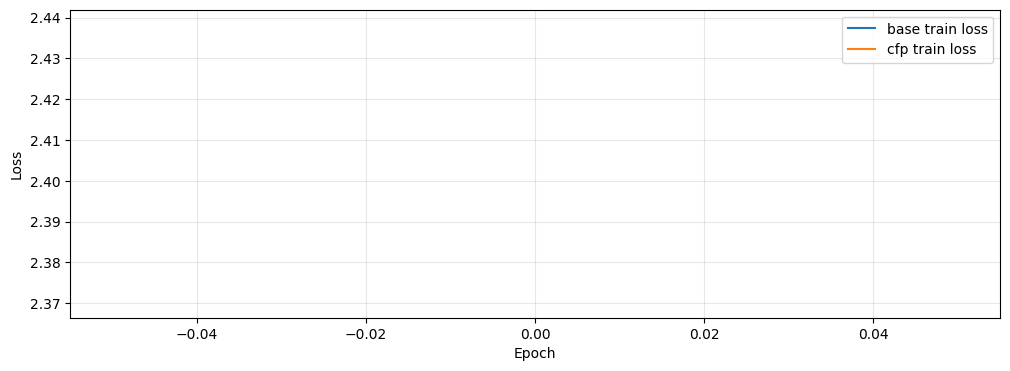

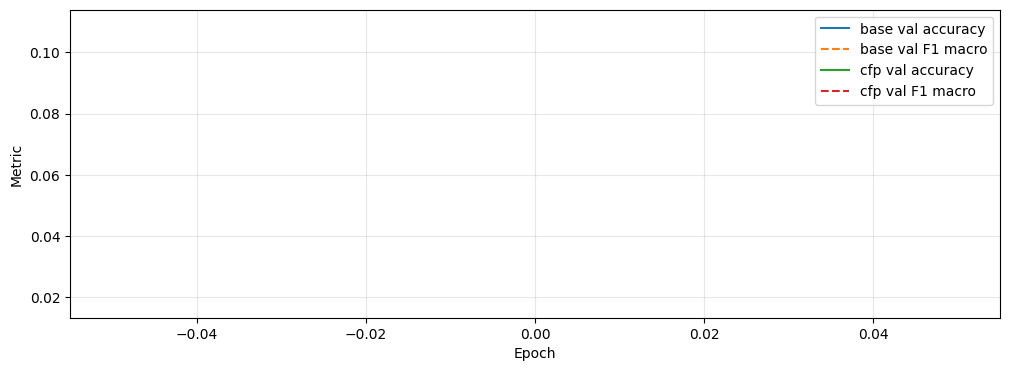

In [13]:
plot_history(("base", history_base), ("cfp", history_cfp))

## Evaluation

In [14]:
metrics_base, y_true_base, y_pred_base, prob_base = evaluate_model(model_base, testloader)
metrics_cfp, y_true_cfp, y_pred_cfp, prob_cfp = evaluate_model(model_cfp, testloader_cfp)

results_df_base = pd.DataFrame([metrics_base])
results_df = pd.DataFrame([metrics_cfp])

display(pd.concat({"base": results_df_base, "cfp": results_df}, names=["model"]))

,,Accuracy,Balanced Accuracy,F1 Macro,F1 Weighted,AUC OVR Macro
model,,,,,,
base,0,0.078125,0.109307,0.036150,0.037800,0.668105
cfp,0,0.054688,0.090909,0.009428,0.005671,0.554315


Baseline classification report
              precision    recall  f1-score   support

     bladder       0.00      0.00      0.00        11
  femur-left       0.11      0.86      0.20         7
 femur-right       0.03      0.25      0.05         8
       heart       0.00      0.00      0.00         2
 kidney-left       0.00      0.00      0.00        14
kidney-right       0.00      0.00      0.00        12
       liver       0.29      0.10      0.14        21
   lung-left       0.00      0.00      0.00        11
  lung-right       0.00      0.00      0.00        17
    pancreas       0.00      0.00      0.00         7
      spleen       0.00      0.00      0.00        18

    accuracy                           0.08       128
   macro avg       0.04      0.11      0.04       128
weighted avg       0.05      0.08      0.04       128

CFP classification report
              precision    recall  f1-score   support

     bladder       0.00      0.00      0.00        11
  femur-left       0.

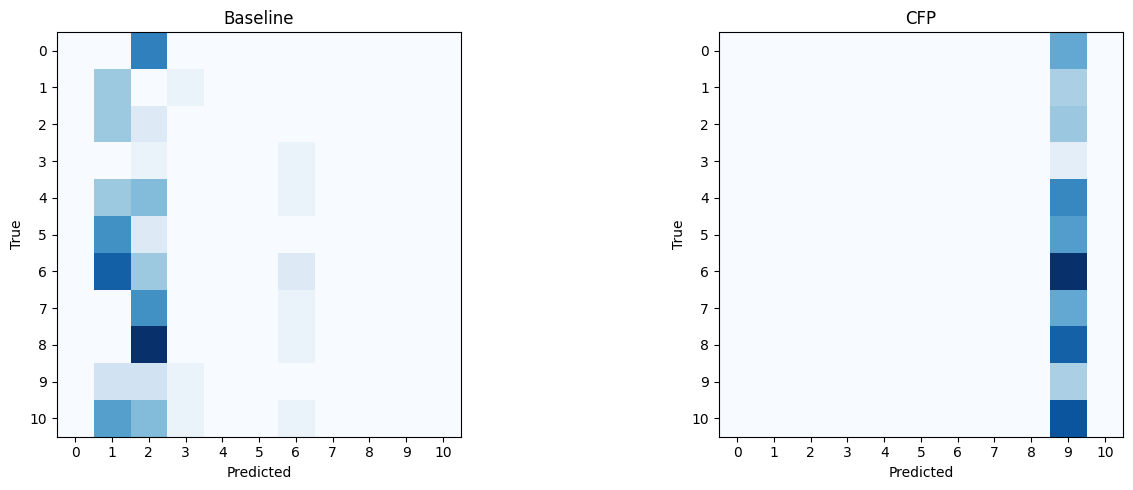

In [15]:
labels = [info["label"][str(i)] for i in range(n_classes)]
print("Baseline classification report")
print(classification_report(y_true_base, y_pred_base, target_names=labels, zero_division=0))
print("CFP classification report")
print(classification_report(y_true_cfp, y_pred_cfp, target_names=labels, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title, y_true, y_pred in [
    (axes[0], "Baseline", y_true_base, y_pred_base),
    (axes[1], "CFP", y_true_cfp, y_pred_cfp),
]:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
plt.tight_layout()
plt.show()

## Save Metrics

In [ ]:
RUN_DIR = Path(OUT_DIR) / f"run_{RUN_ID:03d}"
RUN_DIR.mkdir(parents=True, exist_ok=True)


def save_df(df: pd.DataFrame, name: str):
    df = df.copy()
    df["RUN_ID"] = RUN_ID
    df["SEED"] = SEED
    df["MODEL"] = name
    df["DATASET_FLAG"] = DATASET_FLAG
    df["RESIZE_FACTOR"] = RESIZE_FACTOR
    df["SMOKE_LIMIT"] = SMOKE_LIMIT
    df["NUM_ROWS"] = num_rows
    df["NUM_COLS"] = num_cols
    df["ENCODER_NAME"] = ENCODER_NAME
    df["CACHE_EVAL_CFP"] = CACHE_EVAL_CFP
    df["VAL_CACHE_INDEX_OFFSET"] = VAL_CACHE_INDEX_OFFSET
    df["TEST_CACHE_INDEX_OFFSET"] = TEST_CACHE_INDEX_OFFSET
    df.to_csv(RUN_DIR / f"{name}.csv", index=False)
    try:
        df.to_parquet(RUN_DIR / f"{name}.parquet", index=False)
    except Exception:
        pass

#save_df(results_df_base, "base")
#save_df(results_df, "cfp")
#history_base.to_csv(RUN_DIR / "history_base.csv", index=False)
#history_cfp.to_csv(RUN_DIR / "history_cfp.csv", index=False)
#print("Saved metrics to", RUN_DIR)

Saved metrics to /Users/wonderalexandre/GitHub/mtlearn/notebooks/ICPR2026_run/out_organamnist_unet_resnet18_smoke/runs/run_000
